# GLM

In [1]:
import pandas as pd
import numpy as np
import openpyxl

# Load Excel file
file_path = "/content/fix_cleaned_workcomp.xlsx"
print(file_path)

/content/fix_cleaned_workcomp.xlsx


In [2]:
freq_imputed = pd.read_excel(file_path, sheet_name="freq")
sev_imputed = pd.read_excel(file_path, sheet_name="sev")


SEGMEN: solar_system
    solar_system  n_workers     exposure  claim_count  claim_freq  rel_freq
         Epsilon      55337 27688.258971          712    0.025715  0.901500
Helionis Cluster      26975 13528.757451          399    0.029493  1.033943
            Zeta      52635 26378.213954          801    0.030366  1.064557

SEGMEN: occupation
          occupation  n_workers     exposure  claim_count  claim_freq  rel_freq
       Administrator      13658  6847.475419          107    0.015626  0.609991
      Drill Operator      27138 13555.732474          648    0.047803  1.866046
            Engineer      20000 10023.968344          297    0.029629  1.156610
           Executive       1382   692.448021           10    0.014442  0.563745
   Maintenance Staff       5536  2797.624076           88    0.031455  1.227902
             Manager      20254 10161.919874          185    0.018205  0.710667
Planetary Operations      13525  6735.817995          155    0.023011  0.898280
      Safety O

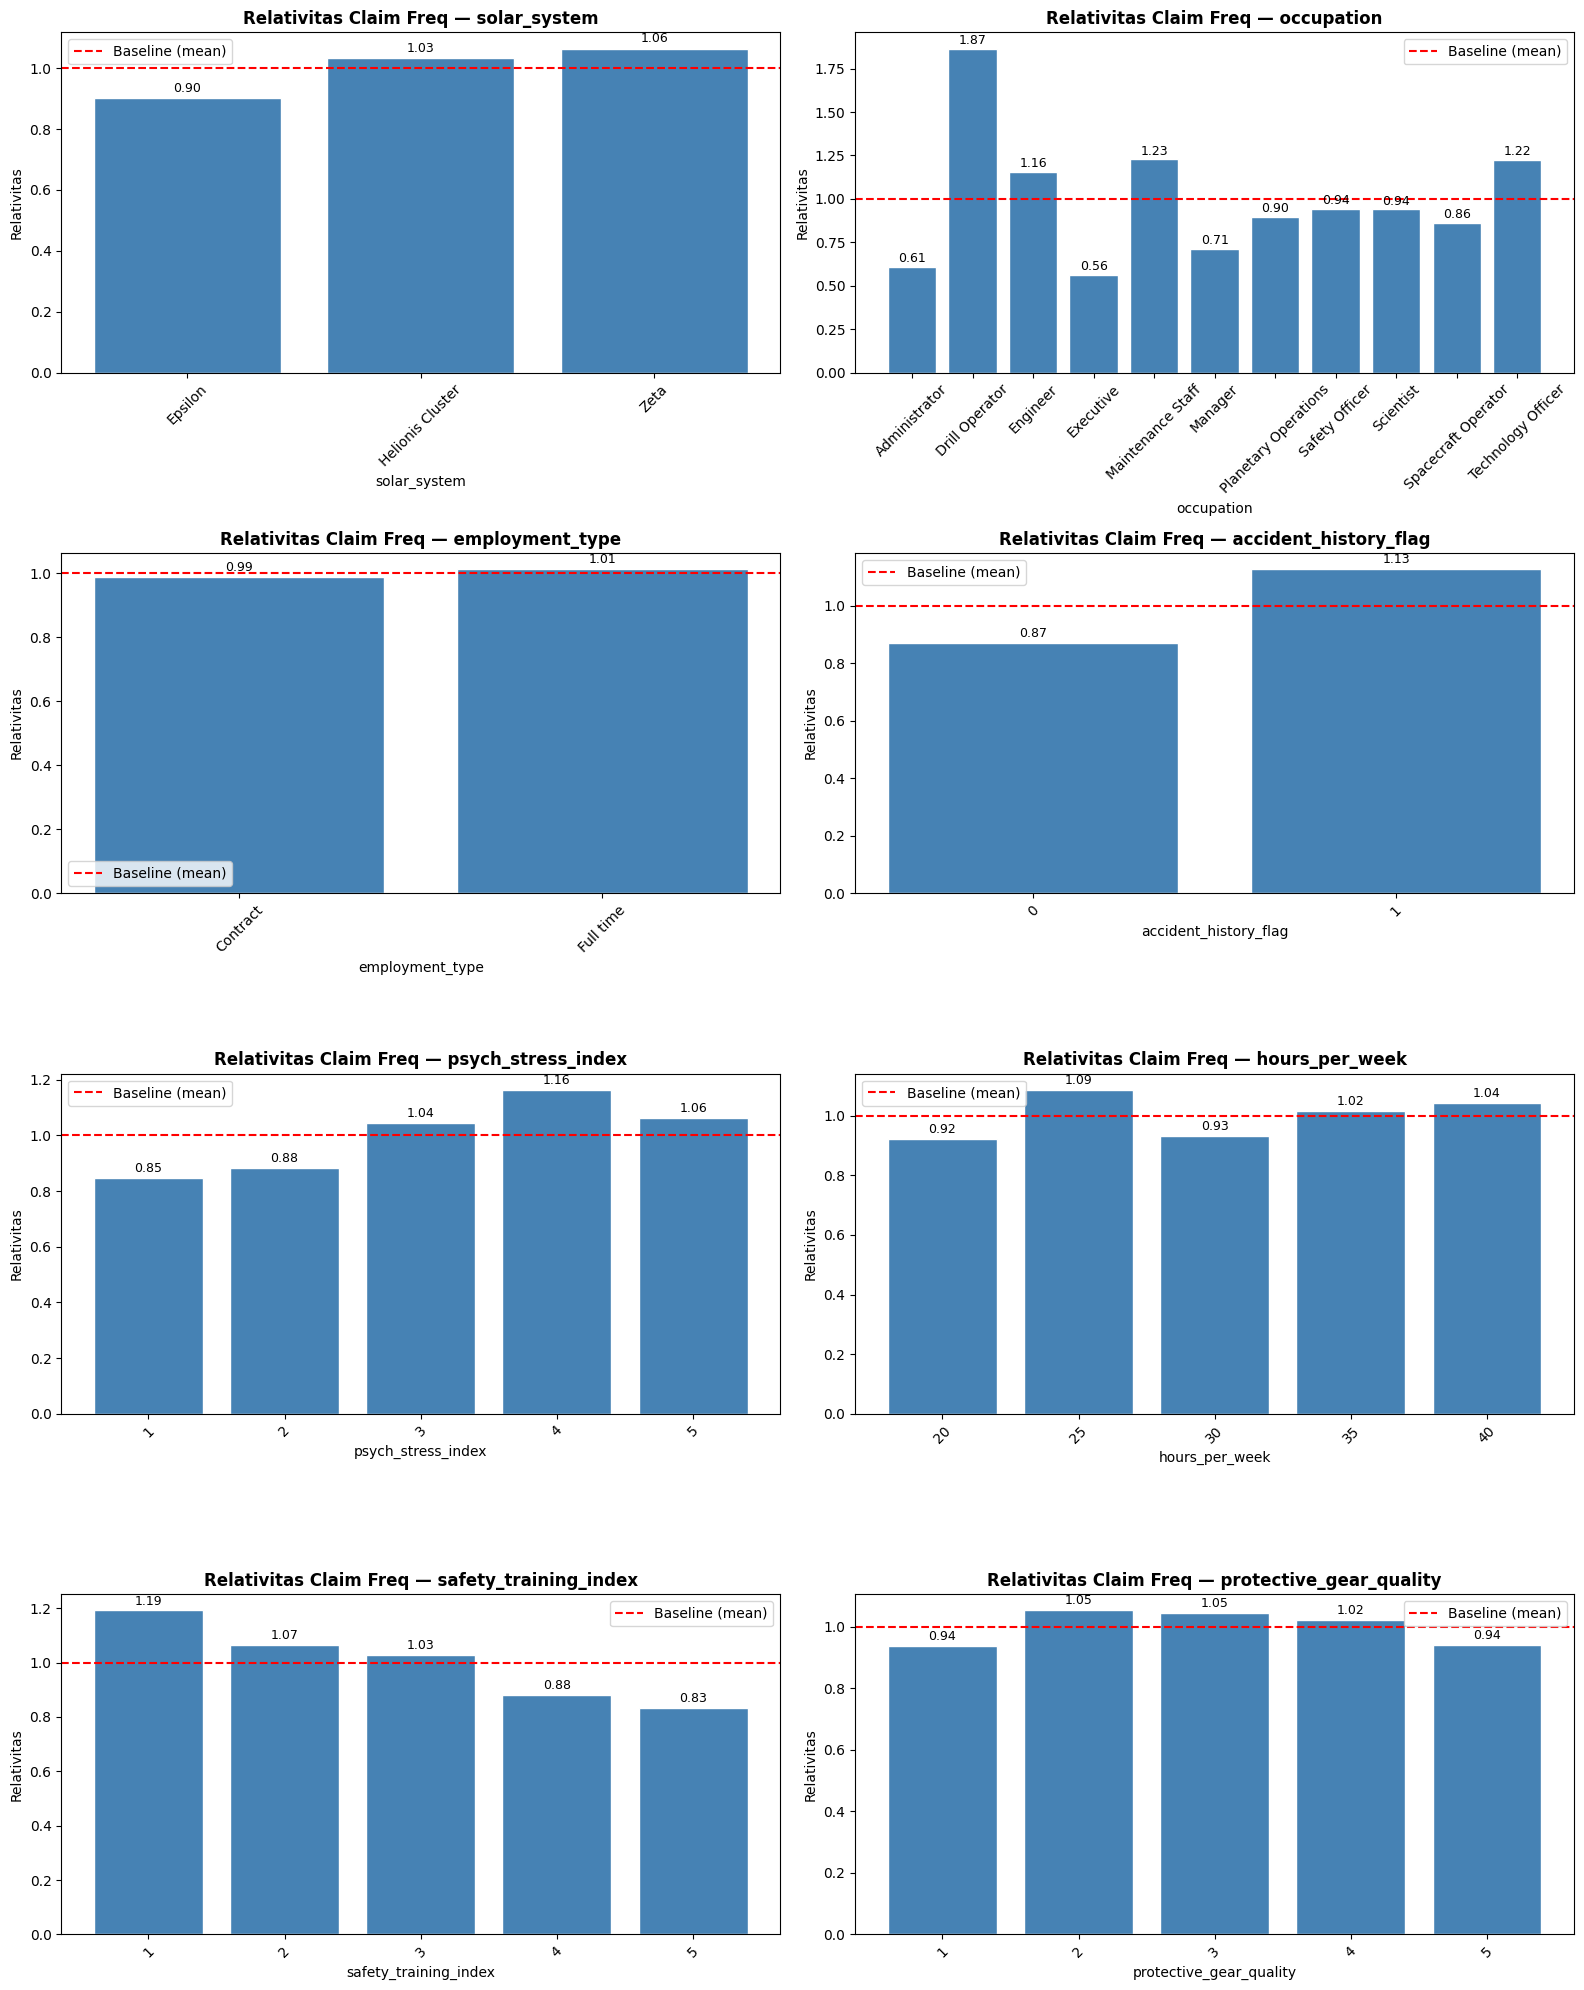


SEGMEN: experience_yrs
experience_yrs_bin  n_workers  claim_freq  rel_freq
     (0.209, 6.98]      27024    0.032568  1.151421
      (6.98, 8.79]      26976    0.036760  1.299602
     (8.79, 10.85]      26970    0.026853  0.949356
    (10.85, 17.32]      26992    0.024998  0.883769
     (17.32, 40.0]      26985    0.020248  0.715852

SEGMEN: supervision_level
supervision_level_bin  n_workers  claim_freq  rel_freq
        (-0.001, 0.1]      30066    0.028785  1.016658
           (0.1, 0.2]      32709    0.027905  0.985553
           (0.2, 0.3]      29215    0.027812  0.982269
           (0.3, 0.4]      20798    0.028043  0.990437
           (0.4, 0.9]      22159    0.029024  1.025082

SEGMEN: gravity_level
gravity_level_bin  n_workers  claim_freq  rel_freq
   (0.749, 0.872]      27087    0.026724  0.944769
   (0.872, 0.994]      27025    0.024619  0.870363
   (0.994, 1.237]      26877    0.029363  1.038061
   (1.237, 1.372]      26974    0.030074  1.063224
     (1.372, 1.5]      26984 

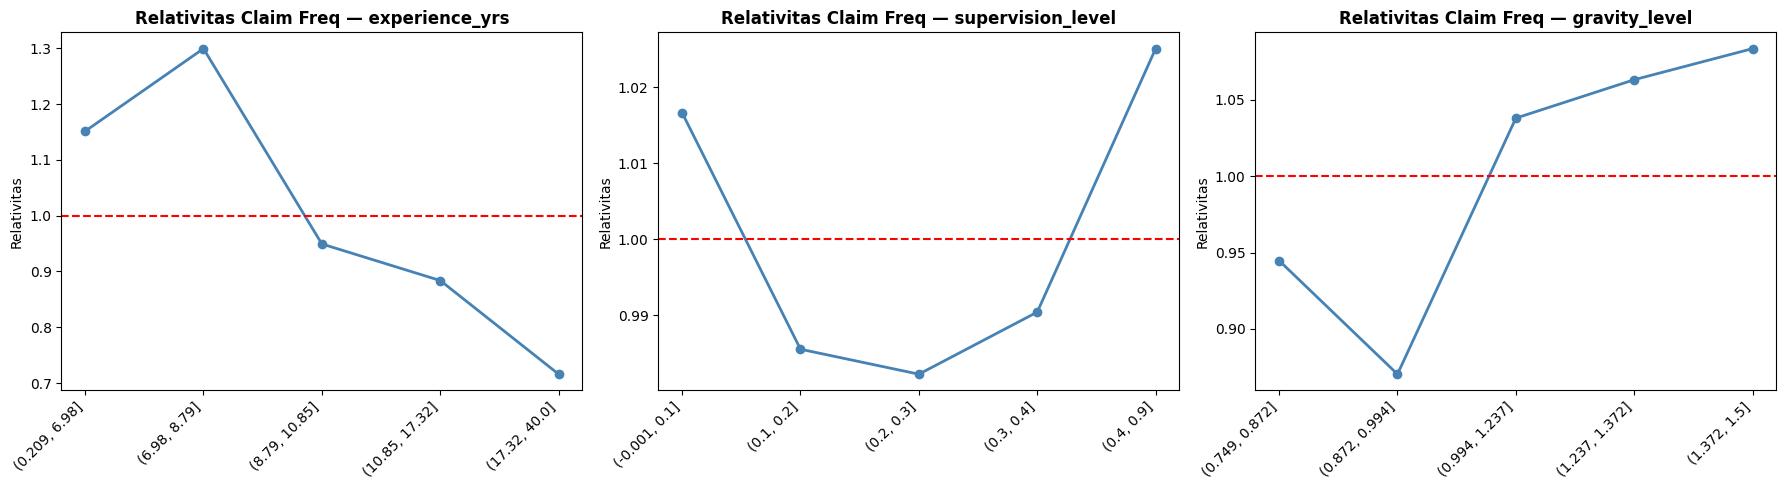


SUMMARY RELATIVITAS PER RATING FACTOR
Nilai > 1.0 → risiko lebih tinggi dari rata-rata
Nilai < 1.0 → risiko lebih rendah dari rata-rata

solar_system:
    solar_system  rel_freq
            Zeta  1.064557
Helionis Cluster  1.033943
         Epsilon  0.901500

occupation:
          occupation  rel_freq
      Drill Operator  1.866046
   Maintenance Staff  1.227902
  Technology Officer  1.224062
            Engineer  1.156610
      Safety Officer  0.942357
           Scientist  0.939099
Planetary Operations  0.898280
 Spacecraft Operator  0.861242
             Manager  0.710667
       Administrator  0.609991
           Executive  0.563745

employment_type:
employment_type  rel_freq
      Full time   1.01229
       Contract   0.98771

accident_history_flag:
 accident_history_flag  rel_freq
                     1  1.128026
                     0  0.871974

psych_stress_index:
 psych_stress_index  rel_freq
                  4  1.163733
                  5  1.062006
                  3  1.04

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. UNIVARIATE ANALYSIS — claim frequency per segmen ──────────────────────
# Merge freq_imputed dengan sev_imputed untuk dapat claim info
# freq sudah punya claim_count dan exposure

df = freq_imputed.copy()

# Claim frequency = claim_count / exposure
df['claim_freq'] = df['claim_count'] / df['exposure']

# ── 2. CATEGORICAL RATING FACTORS ────────────────────────────────────────────
cat_factors = ['solar_system', 'occupation', 'employment_type',
               'accident_history_flag', 'psych_stress_index',
               'hours_per_week', 'safety_training_index', 'protective_gear_quality']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_factors):
    seg = df.groupby(col).agg(
        exposure      = ('exposure', 'sum'),
        claim_count   = ('claim_count', 'sum'),
        n_workers     = (col, 'count')
    ).reset_index()
    seg['claim_freq'] = seg['claim_count'] / seg['exposure']
    seg['rel_freq']   = seg['claim_freq'] / seg['claim_freq'].mean()  # relativitas vs rata-rata

    print(f"\n{'='*50}")
    print(f"SEGMEN: {col}")
    print(seg[[col, 'n_workers', 'exposure', 'claim_count', 'claim_freq', 'rel_freq']].to_string(index=False))

    # Plot
    ax = axes[i]
    bars = ax.bar(seg[col].astype(str), seg['rel_freq'], color='steelblue', edgecolor='white')
    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Baseline (mean)')
    ax.set_title(f'Relativitas Claim Freq — {col}', fontweight='bold')
    ax.set_ylabel('Relativitas')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

    # Annotate bars
    for bar, val in zip(bars, seg['rel_freq']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ── 3. CONTINUOUS RATING FACTORS — binning dulu ──────────────────────────────
cont_factors = ['experience_yrs', 'supervision_level', 'gravity_level']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cont_factors):
    df[f'{col}_bin'] = pd.qcut(df[col], q=5, duplicates='drop')

    seg = df.groupby(f'{col}_bin', observed=True).agg(
        exposure    = ('exposure', 'sum'),
        claim_count = ('claim_count', 'sum'),
        n_workers   = (col, 'count')
    ).reset_index()
    seg['claim_freq'] = seg['claim_count'] / seg['exposure']
    seg['rel_freq']   = seg['claim_freq'] / seg['claim_freq'].mean()

    print(f"\n{'='*50}")
    print(f"SEGMEN: {col}")
    print(seg[[f'{col}_bin', 'n_workers', 'claim_freq', 'rel_freq']].to_string(index=False))

    ax = axes[i]
    ax.plot(range(len(seg)), seg['rel_freq'], marker='o', color='steelblue', linewidth=2)
    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xticks(range(len(seg)))
    ax.set_xticklabels([str(x) for x in seg[f'{col}_bin']], rotation=45, ha='right')
    ax.set_title(f'Relativitas Claim Freq — {col}', fontweight='bold')
    ax.set_ylabel('Relativitas')

plt.tight_layout()
plt.show()

# ── 4. SUMMARY TABEL RELATIVITAS ─────────────────────────────────────────────
print("\n" + "="*60)
print("SUMMARY RELATIVITAS PER RATING FACTOR")
print("="*60)
print("Nilai > 1.0 → risiko lebih tinggi dari rata-rata")
print("Nilai < 1.0 → risiko lebih rendah dari rata-rata")

for col in cat_factors:
    seg = df.groupby(col).agg(
        claim_count = ('claim_count', 'sum'),
        exposure    = ('exposure', 'sum')
    ).reset_index()
    seg['claim_freq'] = seg['claim_count'] / seg['exposure']
    seg['rel_freq']   = seg['claim_freq'] / seg['claim_freq'].mean()
    seg = seg.sort_values('rel_freq', ascending=False)
    print(f"\n{col}:")
    print(seg[[col, 'rel_freq']].to_string(index=False))

In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ======================================================
# 1 LOAD DATA
# ======================================================
df = pd.read_excel("fix_cleaned_workcomp.xlsx")

# ======================================================
# 2 DROP IDENTIFIER
# ======================================================
df = df.drop(columns=["policy_id","worker_id"], errors="ignore")

# ======================================================
# 3 TARGET & EXPOSURE
# ======================================================
df["claim_count"] = df["claim_count"].astype(int)
df["exposure"] = df["exposure"].astype(float)

# ======================================================
# 4 NUMERIC VARIABLES
# ======================================================
num_vars = [
    "experience_yrs",
    "psych_stress_index",
    "hours_per_week",
    "supervision_level",
    "gravity_level",
    "safety_training_index",
    "protective_gear_quality",
    "base_salary"
]

for col in num_vars:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ======================================================
# 5 CATEGORICAL VARIABLES
# ======================================================
cat_vars = [
    "solar_system",
    "station_id",
    "occupation",
    "employment_type",
    "accident_history_flag"
]

for col in cat_vars:
    df[col] = df[col].astype("category")

# ======================================================
# 6 CLEAN EXPOSURE
# ======================================================
df = df[df["exposure"] > 0]
df["log_exposure"] = np.log(df["exposure"])

print("\n======================================================")
print("DATA INFO")
print("======================================================")
print("Total observations:", len(df))

# ======================================================
# 7 GLM FORMULA
# ======================================================
formula = """
claim_count ~

C(solar_system) +
C(station_id) +
C(occupation) +
C(employment_type) +
C(accident_history_flag) +

experience_yrs +
psych_stress_index +
hours_per_week +
supervision_level +
gravity_level +
safety_training_index +
protective_gear_quality +
base_salary
"""

# ======================================================
# 8 POISSON MODEL
# ======================================================
model_pois = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Poisson(),
    offset=df["log_exposure"]
).fit()

# ======================================================
# 9 OVERDISPERSION CHECK
# ======================================================
y = df["claim_count"]
y_hat = model_pois.fittedvalues

pearson = ((y - y_hat)**2 / y_hat).sum()
dispersion = pearson / model_pois.df_resid

print("\n======================================================")
print("OVERDISPERSION CHECK")
print("======================================================")
print("Dispersion value:", round(dispersion,3))

# ======================================================
# 10 NEGATIVE BINOMIAL
# ======================================================
model_nb = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.NegativeBinomial(),
    offset=df["log_exposure"]
).fit()

# ======================================================
# 11 MODEL COMPARISON
# ======================================================
comparison = pd.DataFrame({
    "Model":["Poisson","Negative Binomial"],
    "AIC":[model_pois.aic, model_nb.aic],
    "LogLik":[model_pois.llf, model_nb.llf]
})

comparison = comparison.sort_values("AIC")

print("\n======================================================")
print("MODEL COMPARISON")
print("======================================================")
print(comparison)

best_model = model_pois if model_pois.aic < model_nb.aic else model_nb

print("\nBest Model:", type(best_model.family).__name__)

# ======================================================
# 12 RELATIVITY TABLE
# ======================================================
relativity = pd.DataFrame({
    "variable":best_model.params.index,
    "coef":best_model.params.values,
    "pvalue":best_model.pvalues.values
})

relativity["relativity"] = np.exp(relativity["coef"])

print("\n======================================================")
print("RELATIVITY TABLE")
print("======================================================")
print(relativity)

# ======================================================
# 13 SIGNIFICANT VARIABLES
# ======================================================
significant = relativity[
    (relativity["pvalue"] < 0.05) &
    (relativity["variable"] != "Intercept")
].copy()

significant = significant.sort_values("pvalue")

print("\n======================================================")
print("SIGNIFICANT VARIABLES (p < 0.05)")
print("======================================================")
print(significant)

# ======================================================
# 14 VARIABLE IMPORTANCE
# ======================================================
significant["importance"] = significant["coef"].abs()

importance = significant.sort_values(
    "importance",
    ascending=False
)

print("\n======================================================")
print("VARIABLE IMPORTANCE RANKING")
print("======================================================")
print(importance[["variable","relativity","importance"]])


DATA INFO
Total observations: 134947

OVERDISPERSION CHECK
Dispersion value: 0.999


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "



MODEL COMPARISON
               Model           AIC       LogLik
0            Poisson  19407.303675 -9654.651837
1  Negative Binomial  19414.099675 -9658.049837

Best Model: Poisson

RELATIVITY TABLE
                                 variable          coef        pvalue  \
0                               Intercept -4.327275e+00  2.107806e-29   
1     C(solar_system)[T.Helionis Cluster]  9.012075e-02  3.804890e-01   
2                 C(solar_system)[T.Zeta]  1.044906e-01  5.308593e-01   
3                     C(station_id)[T.A2] -1.653989e-01  3.429703e-01   
4                     C(station_id)[T.A3]  1.363916e-01  4.019730e-01   
5                     C(station_id)[T.A4] -1.120915e-01  5.186780e-01   
6                     C(station_id)[T.A5] -1.977194e-03  9.906684e-01   
7                     C(station_id)[T.A6] -1.634702e-01  3.528506e-01   
8                     C(station_id)[T.A7] -3.022317e-01  9.520553e-02   
9                     C(station_id)[T.A8]  1.895830e-02  9.100847e-01

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ===============================
# COPY DATA
# ===============================
df_sev = sev_imputed.copy()

# ===============================
# HANYA CLAIM POSITIF
# ===============================
df_sev = df_sev[df_sev["claim_amount"] > 0]

# ===============================
# DROP IDENTIFIER
# ===============================
df_sev = df_sev.drop(columns=[
    "claim_id",
    "claim_seq",
    "policy_id",
    "worker_id",
    "exposure"
], errors="ignore")

# ===============================
# TARGET
# ===============================
df_sev["claim_amount"] = df_sev["claim_amount"].astype(float)

# ===============================
# NUMERIC VARIABLES
# ===============================
num_vars = [
    "experience_yrs",
    "psych_stress_index",
    "hours_per_week",
    "supervision_level",
    "gravity_level",
    "safety_training_index",
    "protective_gear_quality",
    "base_salary",
    "claim_length"
]

for col in num_vars:
    df_sev[col] = pd.to_numeric(df_sev[col], errors="coerce")

# ===============================
# CATEGORICAL VARIABLES
# ===============================
cat_vars = [
    "solar_system",
    "station_id",
    "occupation",
    "employment_type",
    "accident_history_flag",
    "injury_type",
    "injury_cause"
]

for col in cat_vars:
    df_sev[col] = df_sev[col].astype("category")

print("Severity observations:", len(df_sev))

# ===============================
# FORMULA
# ===============================
formula = """
claim_amount ~

C(solar_system) +
C(station_id) +
C(occupation) +
C(employment_type) +
C(accident_history_flag) +
C(injury_type) +
C(injury_cause) +

experience_yrs +
psych_stress_index +
hours_per_week +
supervision_level +
gravity_level +
safety_training_index +
protective_gear_quality +
base_salary +
claim_length
"""

# ===============================
# GAMMA MODEL
# ===============================
model_gamma = smf.glm(
    formula=formula,
    data=df_sev,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

# ===============================
# LOGNORMAL MODEL
# ===============================
df_sev["log_claim"] = np.log(df_sev["claim_amount"])

formula_lognorm = formula.replace("claim_amount", "log_claim")

model_lognorm = smf.glm(
    formula=formula_lognorm,
    data=df_sev,
    family=sm.families.Gaussian()
).fit()

# ===============================
# INVERSE GAUSSIAN MODEL
# ===============================
model_invgauss = smf.glm(
    formula=formula,
    data=df_sev,
    family=sm.families.InverseGaussian(link=sm.families.links.Log())
).fit()

# ===============================
# MODEL COMPARISON
# ===============================
comparison = pd.DataFrame({
    "Model": ["Gamma","Lognormal","InverseGaussian"],
    "AIC": [
        model_gamma.aic,
        model_lognorm.aic,
        model_invgauss.aic
    ],
    "BIC": [
        model_gamma.bic,
        model_lognorm.bic,
        model_invgauss.bic
    ],
    "LogLik": [
        model_gamma.llf,
        model_lognorm.llf,
        model_invgauss.llf
    ]
})

comparison = comparison.sort_values("AIC")

print("\nModel Comparison")
print(comparison)

# ===============================
# BEST MODEL
# ===============================
best_model = {
    "Gamma": model_gamma,
    "Lognormal": model_lognorm,
    "InverseGaussian": model_invgauss
}[comparison.iloc[0]["Model"]]

print("\nBest Severity Model:", comparison.iloc[0]["Model"])

# ===============================
# RELATIVITY TABLE (BEST MODEL)
# ===============================
relativity = pd.DataFrame({
    "variable": best_model.params.index,
    "coef": best_model.params.values,
    "pvalue": best_model.pvalues.values
})

relativity["relativity"] = np.exp(relativity["coef"])

print("\nRelativity Table")
print(relativity)

# ===============================
# VARIABLE IMPORTANCE
# ===============================
significant = relativity[
    (relativity["pvalue"] < 0.05) &
    (relativity["variable"] != "Intercept")
].copy()

significant["importance"] = significant["coef"].abs()

significant = significant.sort_values(
    "importance",
    ascending=False
)

print("\nVariable Importance (Significant Only)")
print(significant[["variable","relativity","importance"]])

Severity observations: 1912

Model Comparison
             Model           AIC           BIC        LogLik
1        Lognormal   4692.379084 -12757.519465  -2284.189542
2  InverseGaussian  34927.037043 -13977.853025 -17401.518521
0            Gamma  35228.556583 -12661.306553 -17552.278292

Best Severity Model: Lognormal

Relativity Table
                               variable      coef        pvalue  relativity
0                             Intercept  6.210791  2.955476e-48  498.095238
1   C(solar_system)[T.Helionis Cluster]  0.070426  4.052503e-01    1.072965
2               C(solar_system)[T.Zeta]  0.011159  9.341575e-01    1.011221
3                   C(station_id)[T.A2]  0.048005  7.387139e-01    1.049176
4                   C(station_id)[T.A3] -0.204392  1.259986e-01    0.815143
..                                  ...       ...           ...         ...
57                        gravity_level  0.300127  2.394352e-01    1.350031
58                safety_training_index -0.140572  5

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


In [6]:
# ======================================================
# RELATIVITY FREQUENCY
# ======================================================
relativity_freq = pd.DataFrame({
    "variable": best_model.params.index,
    "coef_freq": best_model.params.values,
    "pvalue_freq": best_model.pvalues.values
})

relativity_freq["relativity_freq"] = np.exp(relativity_freq["coef_freq"])

# ======================================================
# RELATIVITY SEVERITY
# ======================================================
relativity_sev = pd.DataFrame({
    "variable": model_gamma.params.index,
    "coef_sev": model_gamma.params.values,
    "pvalue_sev": model_gamma.pvalues.values
})

relativity_sev["relativity_sev"] = np.exp(relativity_sev["coef_sev"])

# ======================================================
# SIGNIFICANT VARIABLES
# ======================================================
freq_sig = relativity_freq[
    (relativity_freq["pvalue_freq"] < 0.05) &
    (relativity_freq["variable"] != "Intercept")
].copy()

sev_sig = relativity_sev[
    (relativity_sev["pvalue_sev"] < 0.05) &
    (relativity_sev["variable"] != "Intercept")
].copy()

# ======================================================
# IMPORTANCE
# ======================================================
freq_sig["importance_freq"] = freq_sig["coef_freq"].abs()
sev_sig["importance_sev"] = sev_sig["coef_sev"].abs()

freq_imp = freq_sig[["variable","importance_freq","relativity_freq"]]
sev_imp = sev_sig[["variable","importance_sev","relativity_sev"]]

# ======================================================
# MERGE FREQUENCY + SEVERITY
# ======================================================
combined = pd.merge(
    freq_imp,
    sev_imp,
    on="variable",
    how="outer"
).fillna(0)

# PURE PREMIUM IMPORTANCE
combined["importance_total"] = (
    combined["importance_freq"] +
    combined["importance_sev"]
)

combined = combined.sort_values(
    "importance_total",
    ascending=False
)

print("\n=================================================")
print("COMBINED VARIABLE IMPORTANCE (FREQ + SEV)")
print("=================================================")
print(combined)


COMBINED VARIABLE IMPORTANCE (FREQ + SEV)
                       variable  importance_freq  relativity_freq  \
0   C(injury_cause)[T.Violence]         0.358711         1.431483   
3           C(station_id)[T.G5]         0.317297         0.728114   
4           C(station_id)[T.G9]         0.365060         0.694155   
9            psych_stress_index         0.278392         1.321004   
1           C(station_id)[T.B2]         0.000000         0.000000   
2           C(station_id)[T.G2]         0.000000         0.000000   
10        safety_training_index         0.140572         0.868861   
8       protective_gear_quality         0.131029         0.877192   
7                hours_per_week         0.012747         1.012828   
6                  claim_length         0.005196         1.005209   
5                   base_salary         0.000020         1.000020   

    importance_sev  relativity_sev  importance_total  
0         0.691811        1.997330          1.050522  
3         0.609540

# cug liat

In [7]:
# ======================================================
# EXTRACT NAMA VARIABEL UTAMA (HAPUS DUMMY LEVEL)
# ======================================================

combined["variable_main"] = combined["variable"].str.extract(r"C\((.*?)\)")

# jika bukan categorical
combined["variable_main"] = combined["variable_main"].fillna(
    combined["variable"].str.replace(r"\[.*?\]", "", regex=True)
)

# ======================================================
# HITUNG IMPORTANCE TOTAL
# ======================================================

combined["importance_freq"] = combined["importance_freq"].fillna(0)
combined["importance_sev"] = combined["importance_sev"].fillna(0)

combined["importance_total"] = (
    combined["importance_freq"] +
    combined["importance_sev"]
)

# ======================================================
# HITUNG RELATIVITY EFFECT
# ======================================================

combined["rel_effect"] = (
    abs(combined["relativity_freq"].fillna(1) - 1) +
    abs(combined["relativity_sev"].fillna(1) - 1)
)

# ======================================================
# GROUP PER VARIABEL UTAMA
# ======================================================

grouped = combined.groupby("variable_main").agg({
    "importance_freq": "sum",
    "importance_sev": "sum",
    "importance_total": "sum",
    "rel_effect": "sum"
}).reset_index()

# ======================================================
# NORMALISASI
# ======================================================

grouped["imp_norm"] = (
    grouped["importance_total"] /
    grouped["importance_total"].max()
)

grouped["rel_norm"] = (
    grouped["rel_effect"] /
    grouped["rel_effect"].max()
)

# ======================================================
# SCORE BARU (60% RELATIVITY + 40% IMPORTANCE)
# ======================================================

grouped["score"] = (
    0.6 * grouped["rel_norm"] +
    0.4 * grouped["imp_norm"]
)

# ======================================================
# SORT
# ======================================================

grouped = grouped.sort_values("score", ascending=False)

print("\n=================================================")
print("FINAL VARIABLE IMPORTANCE (60% RELATIVITY + 40% IMPORTANCE)")
print("=================================================")

print(grouped[[
    "variable_main",
    "importance_freq",
    "importance_sev",
    "importance_total",
    "rel_effect",
    "score"
]])


FINAL VARIABLE IMPORTANCE (60% RELATIVITY + 40% IMPORTANCE)
             variable_main  importance_freq  importance_sev  importance_total  \
7               station_id         0.682357        1.919399          2.601756   
3             injury_cause         0.358711        0.691811          1.050522   
5       psych_stress_index         0.278392        0.294511          0.572903   
2           hours_per_week         0.012747        0.000000          0.012747   
6    safety_training_index         0.140572        0.164123          0.304696   
4  protective_gear_quality         0.131029        0.134924          0.265953   
1             claim_length         0.005196        0.005176          0.010372   
0              base_salary         0.000020        0.000020          0.000040   

   rel_effect     score  
7    4.093139  1.000000  
3    1.428813  0.370955  
5    0.663473  0.185336  
2    1.012828  0.150427  
6    0.282502  0.088256  
4    0.249026  0.077392  
1    0.010399  0.003119  
0

In [8]:
import pandas as pd
import numpy as np

def monotonic_grouping(rel_table, var_name, n_groups):

    # ambil baris variabel
    temp = rel_table[rel_table["variable"].str.contains(var_name)].copy()

    # ekstrak level kategori
    temp["level"] = temp["variable"].str.extract(r'T\.(.*)\]')

    # isi relativity yang kosong
    temp["relativity_freq"] = temp["relativity_freq"].fillna(1)
    temp["relativity_sev"] = temp["relativity_sev"].fillna(1)

    # expected risk
    temp["risk"] = temp["relativity_freq"] * temp["relativity_sev"]

    # urutkan berdasarkan risk
    temp = temp.sort_values("risk")

    # buat grup berdasarkan ranking
    temp["risk_group"] = pd.qcut(
        temp["risk"],
        q=n_groups,
        labels=[f"G{i+1}" for i in range(n_groups)],
        duplicates="drop"
    )

    return temp[["level","risk","risk_group"]]

In [9]:
# ── GROUPING VARIABEL BERDASARKAN RISIKO ──────────────────────────────────────

# ── 1. OCCUPATION → 3 grup berdasarkan claim frequency ───────────────────────
freq_occ = (
    freq_imputed.groupby('occupation')
    .apply(lambda x: x['claim_count'].sum() / x['exposure'].sum())
    .reset_index()
    .rename(columns={0: 'freq'})
    .sort_values('freq')
)

# Bagi jadi 3 grup berdasarkan quantile frequency
freq_occ['occ_group'] = pd.qcut(freq_occ['freq'], q=3, labels=['Low', 'Mid', 'High'])

print("=== OCCUPATION GROUPING (by claim frequency) ===")
print(freq_occ[['occupation', 'freq', 'occ_group']].to_string(index=False))

# Map ke freq_imputed
occ_map = freq_occ.set_index('occupation')['occ_group'].to_dict()
freq_imputed['occ_group'] = freq_imputed['occupation'].map(occ_map)

# ── 2. STATION_ID → 3 grup berdasarkan claim amount ──────────────────────────
freq_station = (
    sev_imputed.groupby('station_id')['claim_amount']
    .mean()
    .reset_index()
    .rename(columns={'claim_amount': 'avg_amount'})
    .sort_values('avg_amount')
)

freq_station['station_group'] = pd.qcut(freq_station['avg_amount'], q=3, labels=['Low', 'Mid', 'High'])

print("\n=== STATION_ID GROUPING (by avg claim amount) ===")
print(freq_station[['station_id', 'avg_amount', 'station_group']].to_string(index=False))

stn_map = freq_station.set_index('station_id')['station_group'].to_dict()
freq_imputed['station_group'] = freq_imputed['station_id'].map(stn_map)
sev_imputed['station_group']  = sev_imputed['station_id'].map(stn_map)

# ── 3. PROTECTIVE GEAR QUALITY → 2 grup berdasarkan claim amount ─────────────
freq_gear = (
    sev_imputed.groupby('protective_gear_quality')['claim_amount']
    .mean()
    .reset_index()
    .rename(columns={'claim_amount': 'avg_amount'})
    .sort_values('avg_amount')
)

# 2 grup: split di median
median_gear = freq_gear['avg_amount'].median()
freq_gear['gear_group'] = freq_gear['avg_amount'].apply(
    lambda x: 'Low' if x <= median_gear else 'High'
)

print("\n=== PROTECTIVE GEAR QUALITY GROUPING (by avg claim amount) ===")
print(freq_gear[['protective_gear_quality', 'avg_amount', 'gear_group']].to_string(index=False))

gear_map = freq_gear.set_index('protective_gear_quality')['gear_group'].to_dict()
freq_imputed['gear_group'] = freq_imputed['protective_gear_quality'].map(gear_map)
sev_imputed['gear_group']  = sev_imputed['protective_gear_quality'].map(gear_map)

# ── 4. ACCIDENT HISTORY FLAG → sudah 2 kategori (0/1) ────────────────────────
freq_imputed['accident_group'] = freq_imputed['accident_history_flag'].map({0: 'No', 1: 'Yes'})
sev_imputed['accident_group']  = sev_imputed['accident_history_flag'].map({0: 'No', 1: 'Yes'})

print("\n=== ACCIDENT HISTORY FLAG (no grouping needed) ===")
print(freq_imputed['accident_group'].value_counts())

# ── 5. RINGKASAN ──────────────────────────────────────────────────────────────
print("\n=== RINGKASAN GRUP ===")
for col, grp in [('occupation','occ_group'), ('station_id','station_group'),
                  ('protective_gear_quality','gear_group'), ('accident_history_flag','accident_group')]:
    print(f"\n{col} → {grp}:")
    print(freq_imputed[grp].value_counts().sort_index())

/tmp/ipykernel_490/228921976.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['claim_count'].sum() / x['exposure'].sum())


=== OCCUPATION GROUPING (by claim frequency) ===
          occupation     freq occ_group
           Executive 0.014442       Low
       Administrator 0.015626       Low
             Manager 0.018205       Low
 Spacecraft Operator 0.022063       Low
Planetary Operations 0.023011       Mid
           Scientist 0.024057       Mid
      Safety Officer 0.024140       Mid
            Engineer 0.029629      High
  Technology Officer 0.031357      High
   Maintenance Staff 0.031455      High
      Drill Operator 0.047803      High

=== STATION_ID GROUPING (by avg claim amount) ===
station_id   avg_amount station_group
        B3  4929.231212           Low
        G2  5660.613059           Low
        B1  5757.160308           Low
        A7  6006.555185           Low
        G9  6059.656354           Low
        A4  6083.336508           Low
        A8  6114.665417           Low
        G8  6416.574342           Low
        A9  6595.362667           Low
        B2  6680.403380           Mid
  

# FIX SEGMEN

In [10]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# ── 1. OCCUPATION → 3 grup, target: claim frequency, impurity: MSE ───────────
freq_occ = (
    freq_imputed.groupby('occupation')
    .apply(lambda x: x['claim_count'].sum() / x['exposure'].sum())
    .reset_index()
    .rename(columns={0: 'freq'})
)

# Encode occupation ke integer
occ_encoded = pd.Categorical(freq_occ['occupation']).codes.reshape(-1, 1)

dt_occ = DecisionTreeRegressor(max_leaf_nodes=3, random_state=42)
dt_occ.fit(occ_encoded, freq_occ['freq'])
freq_occ['occ_group'] = dt_occ.apply(occ_encoded)  # leaf node id sebagai grup

# Rename leaf id ke Low/Mid/High berdasarkan mean freq per grup
leaf_freq = freq_occ.groupby('occ_group')['freq'].mean().sort_values()
leaf_map  = {leaf: label for leaf, label in zip(leaf_freq.index, ['Low', 'Mid', 'High'])}
freq_occ['occ_group'] = freq_occ['occ_group'].map(leaf_map)

print("=== OCCUPATION GROUPING (Decision Tree, MSE) ===")
print(freq_occ[['occupation', 'freq', 'occ_group']].sort_values('freq').to_string(index=False))

occ_map = freq_occ.set_index('occupation')['occ_group'].to_dict()
freq_imputed['occ_group'] = freq_imputed['occupation'].map(occ_map)

# ── 2. STATION_ID → 3 grup, target: claim amount, impurity: MSE ──────────────
stn_amt = (
    sev_imputed.groupby('station_id')['claim_amount']
    .mean().reset_index()
    .rename(columns={'claim_amount': 'avg_amount'})
)

stn_encoded = pd.Categorical(stn_amt['station_id']).codes.reshape(-1, 1)

dt_stn = DecisionTreeRegressor(max_leaf_nodes=3, random_state=42)
dt_stn.fit(stn_encoded, stn_amt['avg_amount'])
stn_amt['station_group'] = dt_stn.apply(stn_encoded)

leaf_stn = stn_amt.groupby('station_group')['avg_amount'].mean().sort_values()
leaf_map  = {leaf: label for leaf, label in zip(leaf_stn.index, ['Low', 'Mid', 'High'])}
stn_amt['station_group'] = stn_amt['station_group'].map(leaf_map)

print("\n=== STATION_ID GROUPING (Decision Tree, MSE) ===")
print(stn_amt[['station_id', 'avg_amount', 'station_group']].sort_values('avg_amount').to_string(index=False))

stn_map = stn_amt.set_index('station_id')['station_group'].to_dict()
freq_imputed['station_group'] = freq_imputed['station_id'].map(stn_map)
sev_imputed['station_group']  = sev_imputed['station_id'].map(stn_map)

# ── 3. PROTECTIVE GEAR → 2 grup, target: claim amount, impurity: MSE ─────────
gear_amt = (
    sev_imputed.groupby('protective_gear_quality')['claim_amount']
    .mean().reset_index()
    .rename(columns={'claim_amount': 'avg_amount'})
)

gear_encoded = gear_amt['protective_gear_quality'].values.reshape(-1, 1)

dt_gear = DecisionTreeRegressor(max_leaf_nodes=2, random_state=42)
dt_gear.fit(gear_encoded, gear_amt['avg_amount'])
gear_amt['gear_group'] = dt_gear.apply(gear_encoded)

leaf_gear = gear_amt.groupby('gear_group')['avg_amount'].mean().sort_values()
leaf_map  = {leaf: label for leaf, label in zip(leaf_gear.index, ['Low', 'High'])}
gear_amt['gear_group'] = gear_amt['gear_group'].map(leaf_map)

print("\n=== PROTECTIVE GEAR QUALITY GROUPING (Decision Tree, MSE) ===")
print(gear_amt[['protective_gear_quality', 'avg_amount', 'gear_group']].to_string(index=False))

gear_map = gear_amt.set_index('protective_gear_quality')['gear_group'].to_dict()
freq_imputed['gear_group'] = freq_imputed['protective_gear_quality'].map(gear_map)
sev_imputed['gear_group']  = sev_imputed['protective_gear_quality'].map(gear_map)

# ── 4. ACCIDENT HISTORY FLAG → langsung 0/1 ──────────────────────────────────
freq_imputed['accident_group'] = freq_imputed['accident_history_flag'].map({0: 'No', 1: 'Yes'})
sev_imputed['accident_group']  = sev_imputed['accident_history_flag'].map({0: 'No', 1: 'Yes'})

# ── 5. RINGKASAN ──────────────────────────────────────────────────────────────
print("\n=== RINGKASAN DISTRIBUSI GRUP ===")
for grp in ['occ_group', 'station_group', 'gear_group', 'accident_group']:
    print(f"\n{grp}:")
    print(freq_imputed[grp].value_counts().sort_index())

=== OCCUPATION GROUPING (Decision Tree, MSE) ===
          occupation     freq occ_group
           Executive 0.014442       Mid
       Administrator 0.015626       Low
             Manager 0.018205       Mid
 Spacecraft Operator 0.022063       Mid
Planetary Operations 0.023011       Mid
           Scientist 0.024057       Mid
      Safety Officer 0.024140       Mid
            Engineer 0.029629      High
  Technology Officer 0.031357       Mid
   Maintenance Staff 0.031455       Mid
      Drill Operator 0.047803      High

=== STATION_ID GROUPING (Decision Tree, MSE) ===
station_id   avg_amount station_group
        B3  4929.231212           Low
        G2  5660.613059           Low
        B1  5757.160308           Low
        A7  6006.555185           Low
        G9  6059.656354           Low
        A4  6083.336508           Mid
        A8  6114.665417           Low
        G8  6416.574342           Low
        A9  6595.362667           Low
        B2  6680.403380           Low
   

/tmp/ipykernel_490/946065712.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['claim_count'].sum() / x['exposure'].sum())


# SHAP GBM

Data shape: (134947, 12)
Total claims: 1912
Train: 107,957 | Test: 26,990
[0]	validation_0-poisson-nloglik:0.08610
[50]	validation_0-poisson-nloglik:0.08518
[100]	validation_0-poisson-nloglik:0.08511
[120]	validation_0-poisson-nloglik:0.08515

Best iteration: 100

=== PREDICTED vs ACTUAL ===
Actual mean freq    : 0.027866
GBM mean freq       : 0.047217
GLM mean freq       : 0.028288

=== GINI COEFFICIENT ===
GLM Poisson : -0.1465
GBM Poisson : -0.1870
Improvement : -0.0405 (27.6%)

Calculating SHAP values...


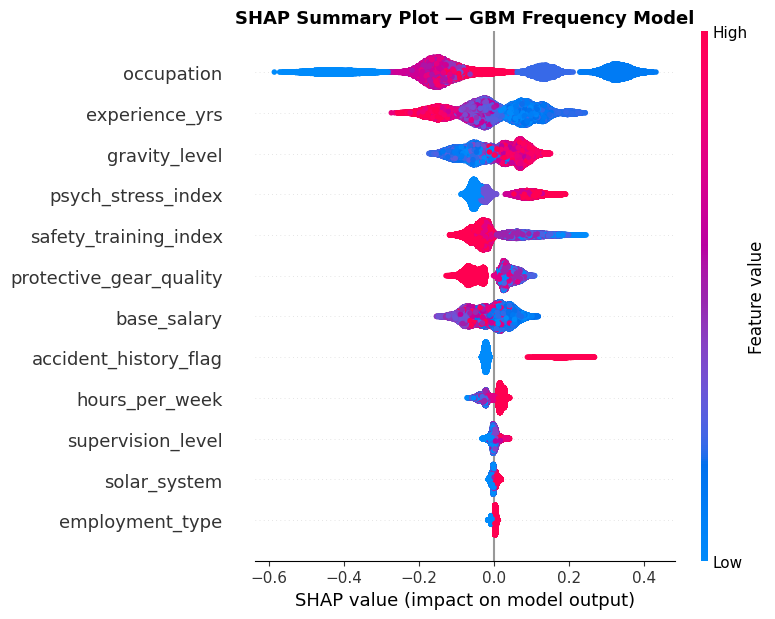

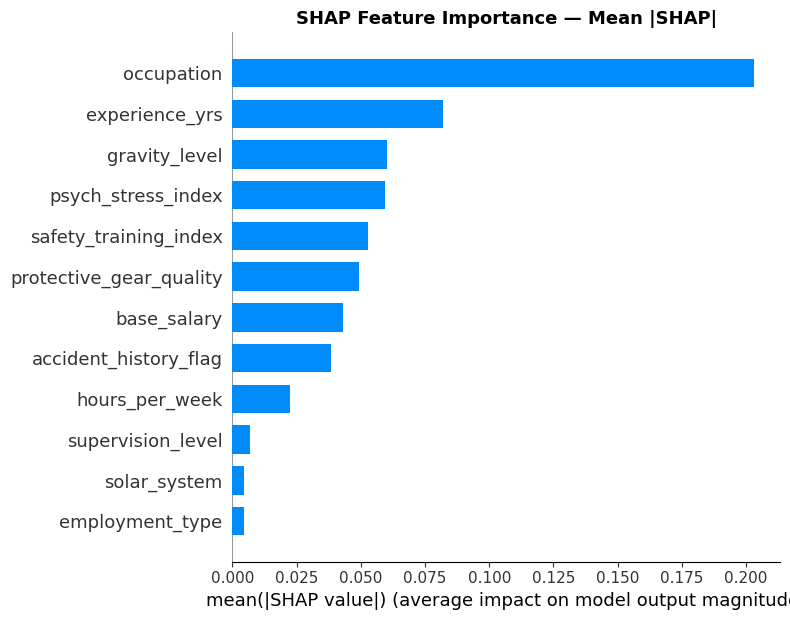

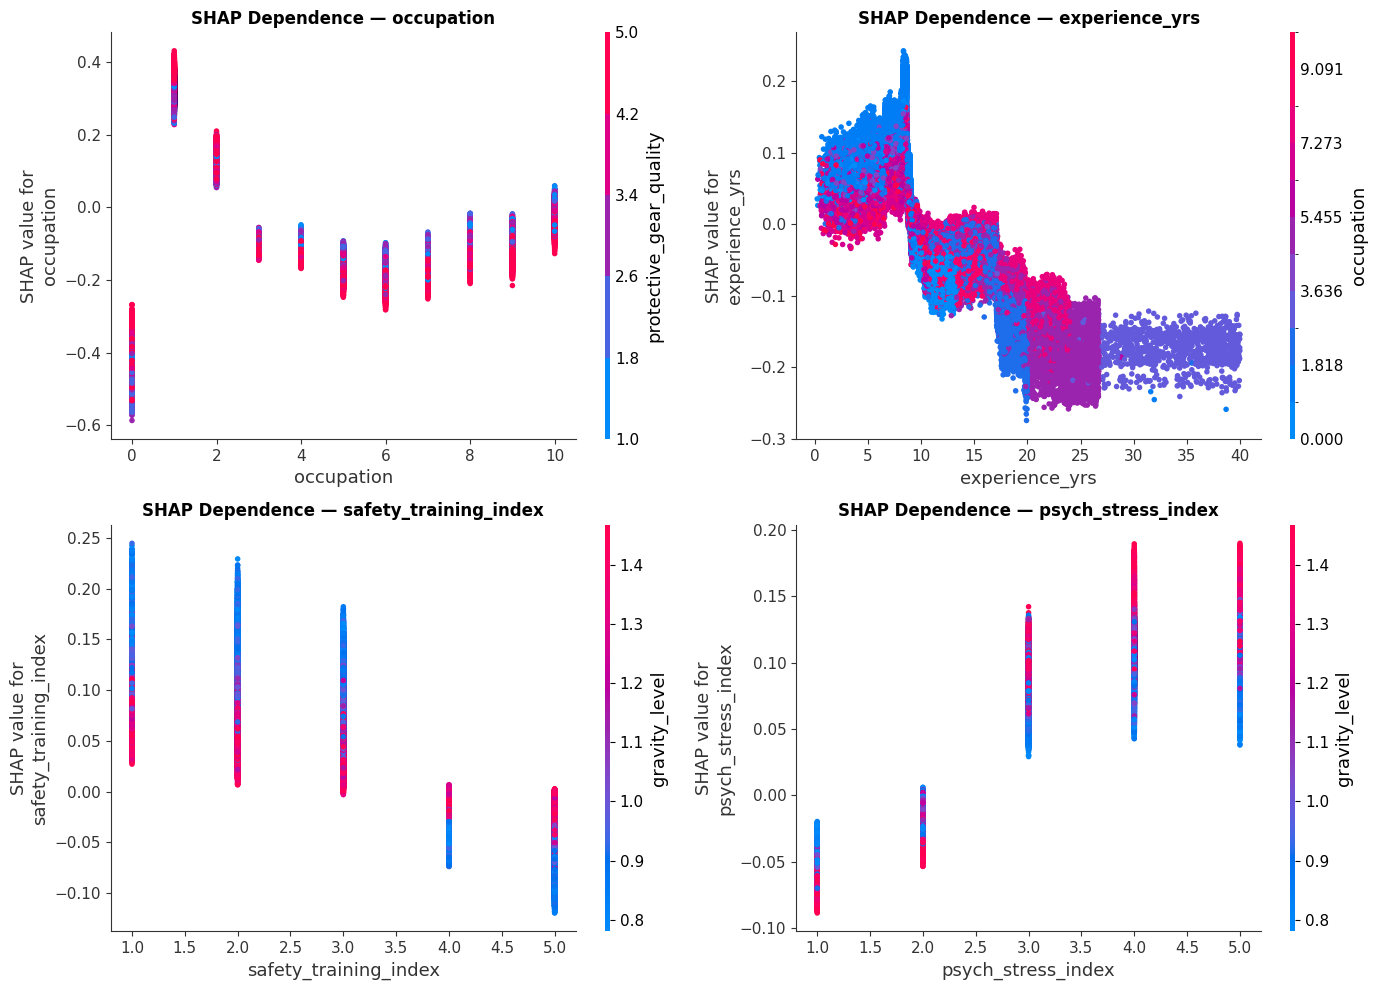

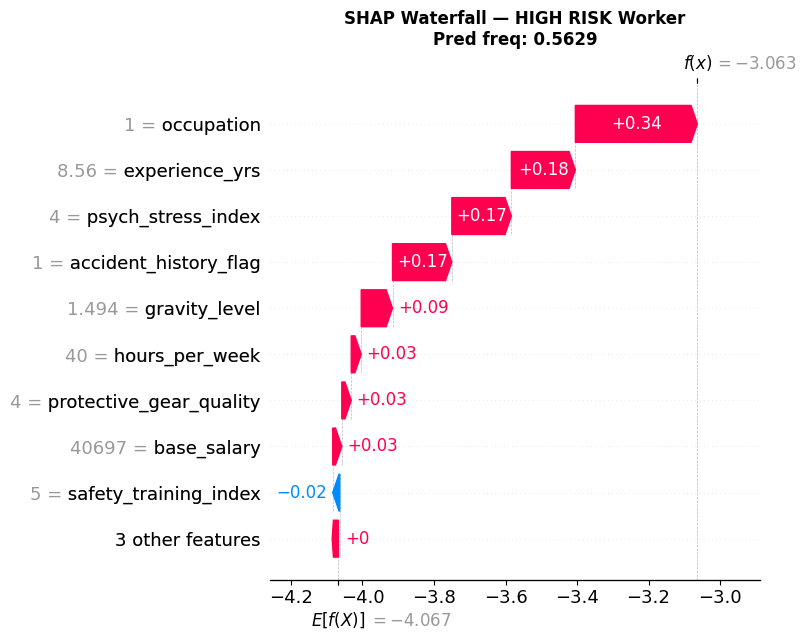

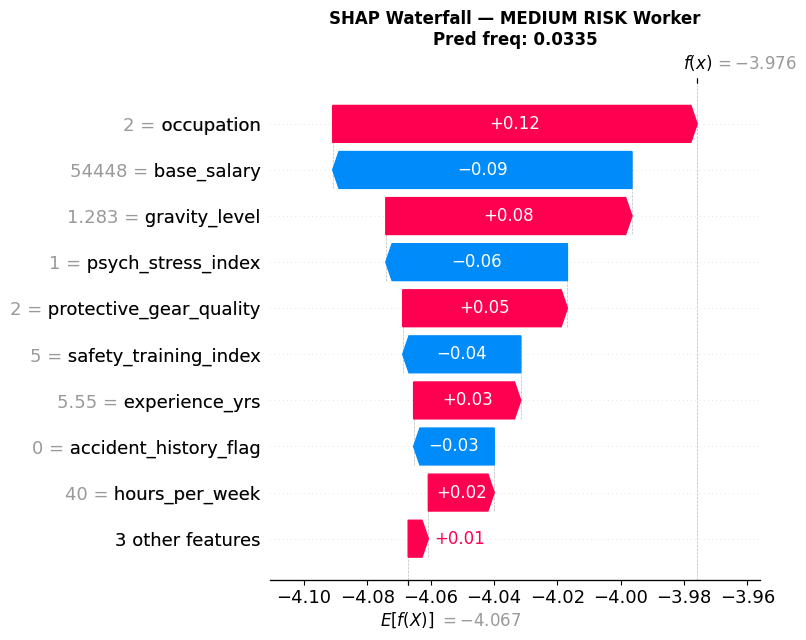

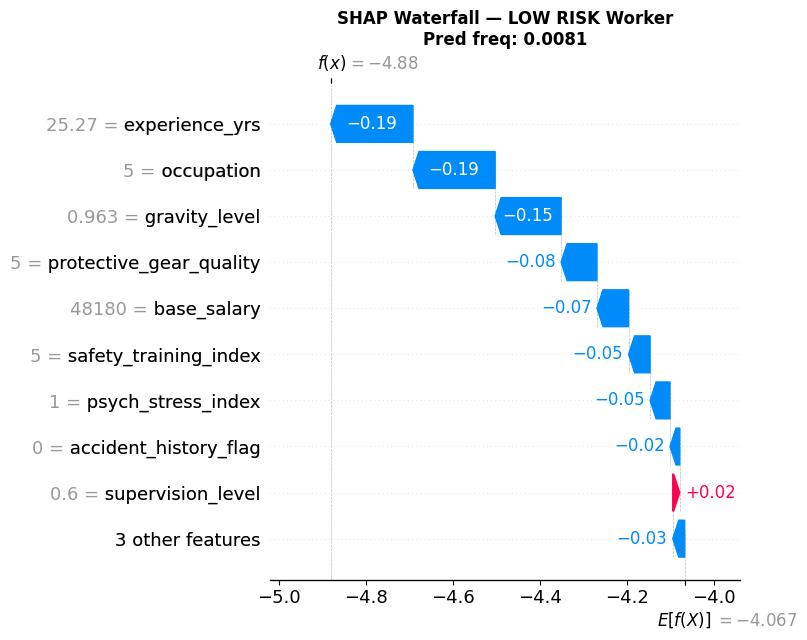


SUMMARY: GLM vs GBM
Metric                                GLM        GBM
Gini Coefficient                  -0.1465    -0.1870
Mean Pred Freq                   0.028288   0.047217
N Features Used                         4         12

Rekomendasi: GLM (cukup, lebih simple)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from xgboost import XGBRegressor, XGBClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance
import warnings
warnings.filterwarnings('ignore')

# ── 1. PREP DATA ──────────────────────────────────────────────────────────────
df_gbm = freq_imputed.copy()

# Features yang masuk (semua rating factors — biarkan GBM yang seleksi)
features = ['occupation', 'solar_system', 'employment_type',
            'experience_yrs', 'accident_history_flag', 'psych_stress_index',
            'hours_per_week', 'supervision_level', 'gravity_level',
            'safety_training_index', 'protective_gear_quality', 'base_salary']

target  = 'claim_count'
offset  = 'exposure'

# Encode categorical ke integer
le_dict = {}
for col in ['occupation', 'solar_system', 'employment_type']:
    le = LabelEncoder()
    df_gbm[col] = le.fit_transform(df_gbm[col].astype(str))
    le_dict[col] = le

# Pastikan semua numerik
for col in features:
    df_gbm[col] = pd.to_numeric(df_gbm[col], errors='coerce')

df_gbm = df_gbm.dropna(subset=features + [target, offset])
df_gbm = df_gbm[df_gbm[offset] > 0].reset_index(drop=True)

X = df_gbm[features]
y = df_gbm[target]
w = df_gbm[offset]  # exposure sebagai sample weight

print(f"Data shape: {X.shape}")
print(f"Total claims: {y.sum():.0f}")

# ── 2. TRAIN / TEST SPLIT ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

# ── 3. FIT GBM POISSON ────────────────────────────────────────────────────────
# XGBoost dengan objective Poisson — equivalent dengan GLM Poisson tapi lebih fleksibel
gbm_model = XGBRegressor(
    objective='count:poisson',   # Poisson regression
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,                 # shallow tree — hindari overfit
    min_child_weight=50,         # minimum exposure per leaf
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,               # L1 regularization
    reg_lambda=1.0,              # L2 regularization
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
    eval_metric='poisson-nloglik'
)

gbm_model.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_test, y_test)],
    sample_weight_eval_set=[w_test],
    verbose=50
)

print(f"\nBest iteration: {gbm_model.best_iteration}")

# ── 4. PREDICTED FREQUENCY ────────────────────────────────────────────────────
# GBM predict claim count — bagi exposure untuk dapat frequency
df_gbm['pred_count_gbm'] = gbm_model.predict(X)
df_gbm['pred_freq_gbm']  = df_gbm['pred_count_gbm'] / df_gbm[offset]

# Bandingkan dengan GLM
print("\n=== PREDICTED vs ACTUAL ===")
print(f"Actual mean freq    : {(y / w).mean():.6f}")
print(f"GBM mean freq       : {df_gbm['pred_freq_gbm'].mean():.6f}")
print(f"GLM mean freq       : {freq_imputed['pred_freq'].mean():.6f}")

# ── 5. MODEL COMPARISON — GINI COEFFICIENT ────────────────────────────────────
def gini_coefficient(actual, predicted, weight):
    """Double lift / Gini — standard insurance model comparison metric"""
    df_temp = pd.DataFrame({'actual': actual, 'predicted': predicted, 'weight': weight})

    # Sort by predicted
    df_sorted = df_temp.sort_values('predicted').reset_index(drop=True)

    cum_weight  = df_sorted['weight'].cumsum() / df_sorted['weight'].sum()
    cum_actual  = (df_sorted['actual']).cumsum() / df_sorted['actual'].sum()

    # Gini = 2 * AUC - 1
    auc  = np.trapz(cum_actual, cum_weight)
    gini = 2 * auc - 1
    return gini

# GBM Gini
gini_gbm = gini_coefficient(
    y_test,
    gbm_model.predict(X_test),
    w_test
)

# GLM Gini — pakai pred_freq × exposure sebagai predicted count
glm_pred_test = freq_imputed.loc[X_test.index, 'pred_freq'] * w_test
gini_glm = gini_coefficient(y_test, glm_pred_test, w_test)

print(f"\n=== GINI COEFFICIENT ===")
print(f"GLM Poisson : {gini_glm:.4f}")
print(f"GBM Poisson : {gini_gbm:.4f}")
print(f"Improvement : {(gini_gbm - gini_glm):.4f} ({(gini_gbm/gini_glm - 1)*100:.1f}%)")

# ── 6. SHAP VALUES ────────────────────────────────────────────────────────────
print("\nCalculating SHAP values...")
explainer   = shap.TreeExplainer(gbm_model)
shap_values = explainer(X)

# ── 7. SHAP SUMMARY PLOT ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X,
    feature_names=features,
    show=False
)
plt.title('SHAP Summary Plot — GBM Frequency Model', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# ── 8. SHAP BAR PLOT — FEATURE IMPORTANCE ────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X,
    feature_names=features,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — Mean |SHAP|', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# ── 9. SHAP DEPENDENCE PLOTS — variabel kunci ─────────────────────────────────
key_vars = ['occupation', 'experience_yrs', 'safety_training_index', 'psych_stress_index']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    shap.dependence_plot(
        var,
        shap_values.values,
        X,
        feature_names=features,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'SHAP Dependence — {var}', fontweight='bold')

plt.tight_layout()
plt.show()

# ── 10. SHAP WATERFALL — contoh 3 worker ──────────────────────────────────────
# Worker berisiko tinggi, sedang, rendah
high_risk_idx  = df_gbm['pred_freq_gbm'].nlargest(1).index[0]
mid_risk_idx   = df_gbm.iloc[(df_gbm['pred_freq_gbm'] - df_gbm['pred_freq_gbm'].median()).abs().argsort()[:1]].index[0]
low_risk_idx   = df_gbm['pred_freq_gbm'].nsmallest(1).index[0]

for idx, label in [(high_risk_idx, 'HIGH RISK'), (mid_risk_idx, 'MEDIUM RISK'), (low_risk_idx, 'LOW RISK')]:
    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(shap_values[idx], show=False)
    plt.title(f'SHAP Waterfall — {label} Worker\nPred freq: {df_gbm.loc[idx, "pred_freq_gbm"]:.4f}',
              fontweight='bold')
    plt.tight_layout()
    plt.show()

# ── 11. SUMMARY COMPARISON GLM vs GBM ────────────────────────────────────────
print("\n" + "="*55)
print("SUMMARY: GLM vs GBM")
print("="*55)
print(f"{'Metric':<30} {'GLM':>10} {'GBM':>10}")
print(f"{'Gini Coefficient':<30} {gini_glm:>10.4f} {gini_gbm:>10.4f}")
print(f"{'Mean Pred Freq':<30} {freq_imputed['pred_freq'].mean():>10.6f} {df_gbm['pred_freq_gbm'].mean():>10.6f}")
print(f"{'N Features Used':<30} {'4':>10} {len(features):>10}")
print(f"\nRekomendasi: {'GBM' if gini_gbm > gini_glm + 0.02 else 'GLM (cukup, lebih simple)'}")

[0]	validation_0-tweedie-nloglik@1.5:0.67329
[47]	validation_0-tweedie-nloglik@1.5:0.66421
Actual mean freq : 0.027866
GBM mean freq    : 0.027015
GLM mean freq    : 0.028288

=== GINI (fixed) ===
GLM : 0.2155
GBM : 0.2018
Selisih: 0.0137

Rekomendasi: GLM cukup, lebih simple dan interpretable

Calculating SHAP values...


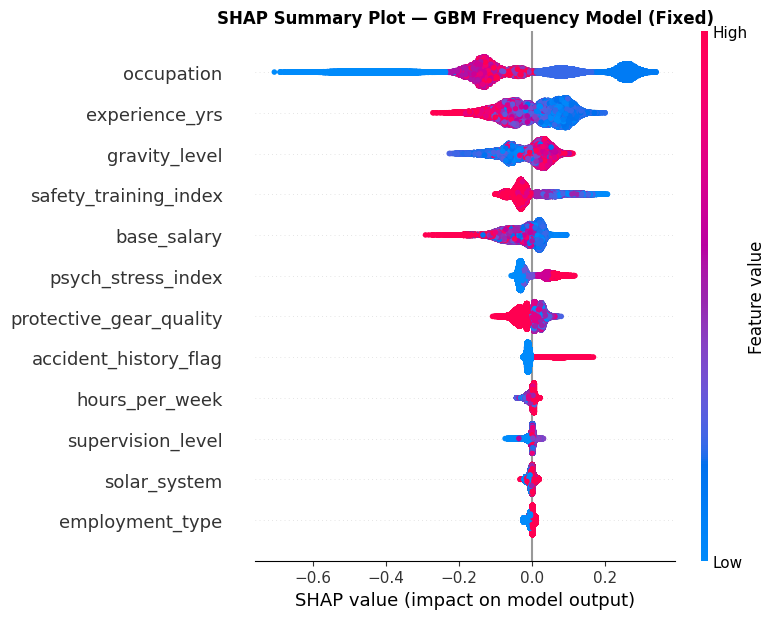

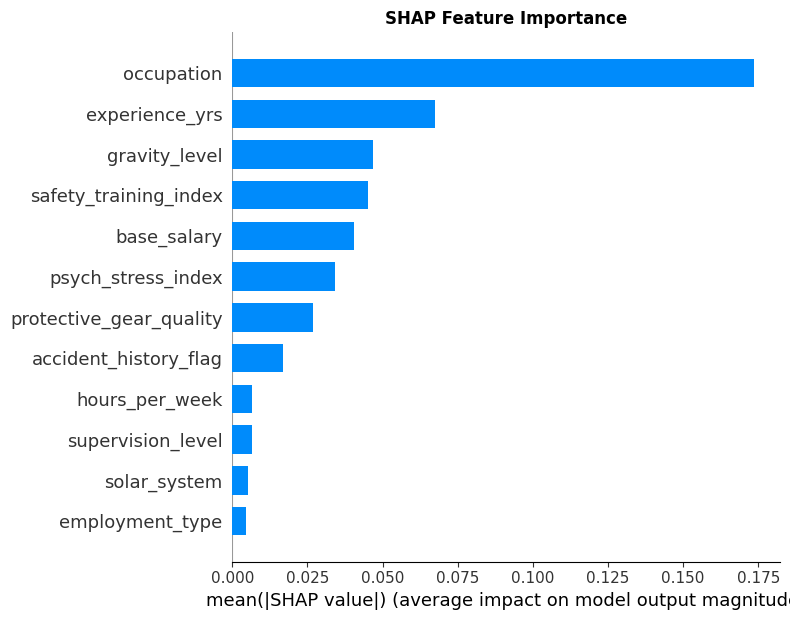

In [ ]:
# ── FIX 1: GBM dengan exposure sebagai offset ─────────────────────────────────
# XGBoost count:poisson predict claim count langsung
# Kita perlu normalize target dengan exposure dulu

df_gbm2 = freq_imputed.copy()

features = ['occupation', 'solar_system', 'employment_type',
            'experience_yrs', 'accident_history_flag', 'psych_stress_index',
            'hours_per_week', 'supervision_level', 'gravity_level',
            'safety_training_index', 'protective_gear_quality', 'base_salary']

# Encode categorical
le_dict2 = {}
for col in ['occupation', 'solar_system', 'employment_type']:
    le = LabelEncoder()
    df_gbm2[col] = le.fit_transform(df_gbm2[col].astype(str))
    le_dict2[col] = le

for col in features:
    df_gbm2[col] = pd.to_numeric(df_gbm2[col], errors='coerce')

df_gbm2 = df_gbm2.dropna(subset=features + ['claim_count', 'exposure'])
df_gbm2 = df_gbm2[df_gbm2['exposure'] > 0].reset_index(drop=True)

# TARGET = claim frequency (bukan claim count)
# sample_weight = exposure
X2 = df_gbm2[features]
y2 = df_gbm2['claim_count'] / df_gbm2['exposure']  # frequency sebagai target
w2 = df_gbm2['exposure']

X_train2, X_test2, y_train2, y_test2, w_train2, w_test2 = train_test_split(
    X2, y2, w2, test_size=0.2, random_state=42
)

# Fit dengan tweedie (lebih stabil untuk frequency)
gbm2 = XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
    eval_metric='tweedie-nloglik@1.5'
)

gbm2.fit(
    X_train2, y_train2,
    sample_weight=w_train2,
    eval_set=[(X_test2, y_test2)],
    sample_weight_eval_set=[w_test2],
    verbose=50
)

df_gbm2['pred_freq_gbm2'] = gbm2.predict(X2)

print(f"Actual mean freq : {y2.mean():.6f}")
print(f"GBM mean freq    : {df_gbm2['pred_freq_gbm2'].mean():.6f}")
print(f"GLM mean freq    : {freq_imputed['pred_freq'].mean():.6f}")

# ── FIX 2: GINI yang benar ────────────────────────────────────────────────────
def gini_coefficient(actual, predicted, weight):
    df_temp = pd.DataFrame({
        'actual'   : np.array(actual),
        'predicted': np.array(predicted),
        'weight'   : np.array(weight)
    }).sort_values('predicted', ascending=True).reset_index(drop=True)

    # Weighted cumulative
    cum_weight = np.cumsum(df_temp['weight']) / df_temp['weight'].sum()
    cum_loss   = np.cumsum(df_temp['actual'] * df_temp['weight']) / (df_temp['actual'] * df_temp['weight']).sum()

    # Area under Lorenz curve
    auc  = np.trapz(cum_loss, cum_weight)
    gini = 1 - 2 * auc  # Gini = 1 - 2*AUC (harusnya positif kalau model bagus)
    return abs(gini)

gini_gbm2 = gini_coefficient(y_test2, gbm2.predict(X_test2), w_test2)

glm_pred_freq_test = freq_imputed.loc[X_test2.index, 'pred_freq']
gini_glm2 = gini_coefficient(y_test2, glm_pred_freq_test, w_test2)

print(f"\n=== GINI (fixed) ===")
print(f"GLM : {gini_glm2:.4f}")
print(f"GBM : {gini_gbm2:.4f}")
print(f"Selisih: {abs(gini_gbm2 - gini_glm2):.4f}")
print(f"\nRekomendasi: {'GBM lebih baik' if gini_gbm2 > gini_glm2 + 0.02 else 'GLM cukup, lebih simple dan interpretable'}")

# ── SHAP (pakai model baru) ───────────────────────────────────────────────────
print("\nCalculating SHAP values...")
explainer2   = shap.TreeExplainer(gbm2)
shap_values2 = explainer2(X2)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values2, X2, feature_names=features, show=False)
plt.title('SHAP Summary Plot — GBM Frequency Model (Fixed)', fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values2, X2, feature_names=features, plot_type='bar', show=False)
plt.title('SHAP Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

# KMEANS

Shape sebelum PCA: (20000, 13)
Komponen PCA untuk 80% variance: 9
Shape setelah PCA: (20000, 9)
k=2 | inertia=178426.2 | silhouette=0.2065
k=3 | inertia=157481.9 | silhouette=0.2272
k=4 | inertia=145846.8 | silhouette=0.1715
k=5 | inertia=138824.6 | silhouette=0.1391
k=6 | inertia=131134.0 | silhouette=0.1517
k=7 | inertia=126461.3 | silhouette=0.1268
k=8 | inertia=118347.5 | silhouette=0.1341
k=9 | inertia=114250.3 | silhouette=0.1267
k=10 | inertia=110162.6 | silhouette=0.1329


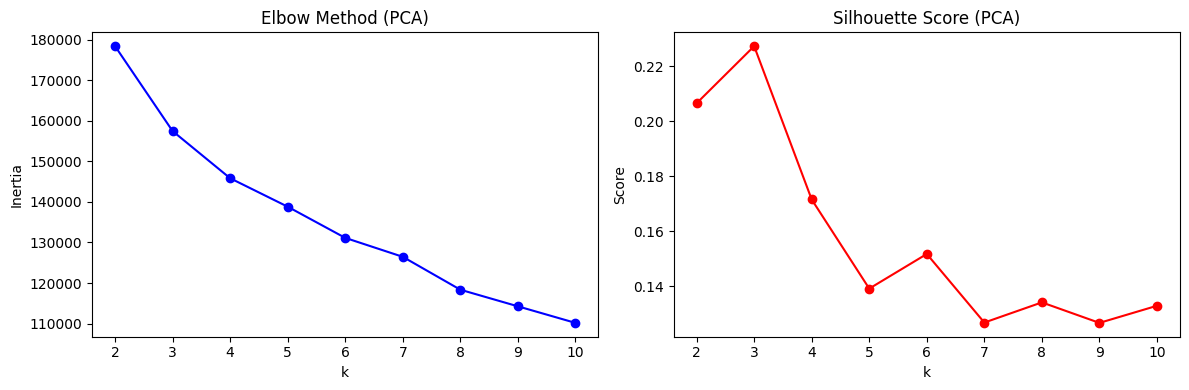


K terbaik (elbow): 2 | silhouette: 0.2065

Distribusi cluster:
cluster
0    80564
1    54383
Name: count, dtype: int64


In [ ]:
# ── 1. SAMPLE & ENCODE ───────────────────────────────────────────────────────
df_sample = freq_imputed.sample(n=20000, random_state=42)

df_km = df_sample.drop(columns=id_cols).copy()
df_km = pd.get_dummies(df_km, columns=[c for c in cat_cols if c not in id_cols], drop_first=False)

num_cols = df_km.select_dtypes(include='number').columns.tolist()
X = df_km[num_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Shape sebelum PCA: {X_scaled.shape}")

# ── 2. PCA ────────────────────────────────────────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumvar >= 0.80) + 1
print(f"Komponen PCA untuk 80% variance: {n_components}")

pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Shape setelah PCA: {X_pca.shape}")

# ── 3. ELBOW + SILHOUETTE ─────────────────────────────────────────────────────
inertia, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))
    print(f"k={k} | inertia={km.inertia_:.1f} | silhouette={sil_scores[-1]:.4f}")

# ── 4. PLOT ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_title('Elbow Method (PCA)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_title('Silhouette Score (PCA)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

# ── 5. PILIH K DARI ELBOW ─────────────────────────────────────────────────────
deltas = np.diff(inertia)
accel  = np.diff(deltas)
best_k = np.argmax(accel) + 2
print(f"\nK terbaik (elbow): {best_k} | silhouette: {sil_scores[best_k-2]:.4f}")

# ── 6. FIT FINAL & PREDICT KE SELURUH DATA ───────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_final.fit(X_pca)

# Encode & transform seluruh freq_imputed
df_full = freq_imputed.drop(columns=id_cols).copy()
df_full = pd.get_dummies(df_full, columns=[c for c in cat_cols if c not in id_cols], drop_first=False)
X_full_scaled = scaler.transform(df_full[num_cols])
X_full_pca    = pca.transform(X_full_scaled)

freq_imputed['cluster'] = km_final.predict(X_full_pca)

print("\nDistribusi cluster:")
print(freq_imputed['cluster'].value_counts().sort_index())

Komponen PCA untuk 80% variance: 10


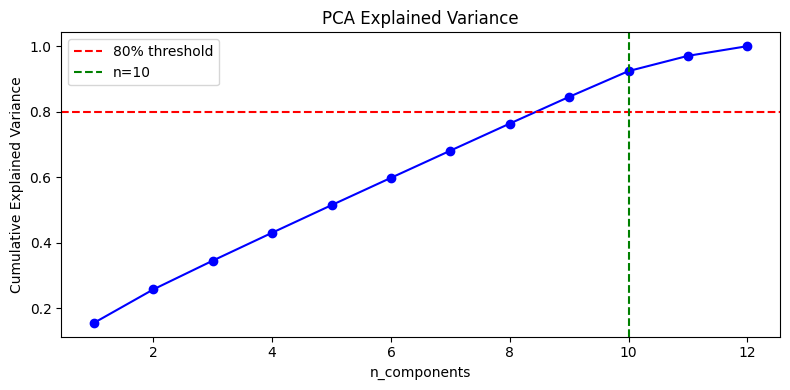

Shape setelah PCA: (20000, 10)
k=2 | inertia=196839.8 | silhouette=0.1241
k=3 | inertia=179053.3 | silhouette=0.1410
k=4 | inertia=166658.2 | silhouette=0.1222
k=5 | inertia=147655.0 | silhouette=0.1330
k=6 | inertia=139818.9 | silhouette=0.1163
k=7 | inertia=133030.4 | silhouette=0.1136
k=8 | inertia=127326.3 | silhouette=0.1115
k=9 | inertia=122635.1 | silhouette=0.1094
k=10 | inertia=119515.4 | silhouette=0.1108


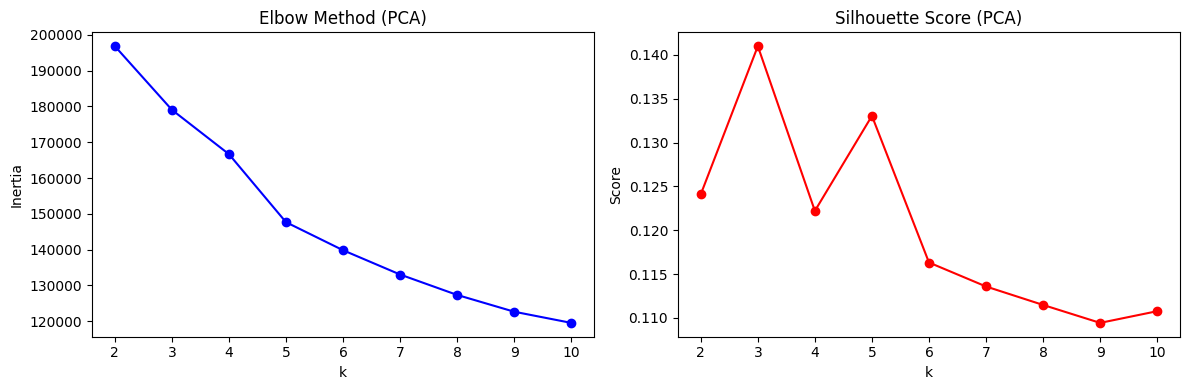


K terbaik: 3 (silhouette=0.1410)

Distribusi cluster:
cluster
0    13549
1    40924
2    80474
Name: count, dtype: int64


In [ ]:
from sklearn.decomposition import PCA

# ── PCA ───────────────────────────────────────────────────────────────────────
# Cari n_components optimal (explain 80% variance)
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumvar >= 0.90) + 1
print(f"Komponen PCA untuk 80% variance: {n_components}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, 'bo-')
plt.axhline(0.80, color='r', linestyle='--', label='80% threshold')
plt.axvline(n_components, color='g', linestyle='--', label=f'n={n_components}')
plt.xlabel('n_components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

# ── Transform ─────────────────────────────────────────────────────────────────
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Shape setelah PCA: {X_pca.shape}")

# ── KMeans ulang ──────────────────────────────────────────────────────────────
inertia, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))
    print(f"k={k} | inertia={km.inertia_:.1f} | silhouette={sil_scores[-1]:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_title('Elbow Method (PCA)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_title('Silhouette Score (PCA)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

# ── Fit final ─────────────────────────────────────────────────────────────────
best_k = sil_scores.index(max(sil_scores)) + 2
print(f"\nK terbaik: {best_k} (silhouette={max(sil_scores):.4f})")

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_final.fit(X_pca)

# Predict ke seluruh freq_imputed
X_full_pca = pca.transform(scaler.transform(df_full[num_cols]))
freq_imputed['cluster'] = km_final.predict(X_full_pca)

print("\nDistribusi cluster:")
print(freq_imputed['cluster'].value_counts().sort_index())

In [ ]:
sev_imputed['claim_id'].nunique()

1912

In [ ]:

print("=== CEK UNIQUENESS ===")
print(f"Total rows              : {freq_imputed.shape[0]:,}")
print(f"\npolicy_id unique        : {freq_imputed['policy_id'].nunique():,}")
print(f"worker_id unique        : {freq_imputed['worker_id'].nunique():,}")
print(f"\nDuplikat policy_id      : {freq_imputed['policy_id'].duplicated().sum():,}")
print(f"Duplikat worker_id      : {freq_imputed['worker_id'].duplicated().sum():,}")

# Cek apakah 1 policy bisa punya banyak worker
print("\n=== WORKERS PER POLICY ===")
print(freq_imputed.groupby('policy_id')['worker_id'].nunique().describe())

# Cek apakah 1 worker bisa ada di banyak policy
print("\n=== POLICIES PER WORKER ===")
print(freq_imputed.groupby('worker_id')['policy_id'].nunique().describe())


=== CEK UNIQUENESS ===
Total rows              : 134,839

policy_id unique        : 2,699
worker_id unique        : 134,532

Duplikat policy_id      : 132,139
Duplikat worker_id      : 306

=== WORKERS PER POLICY ===
count    2699.000000
mean       49.739163
std        40.205497
min         9.000000
25%        21.000000
50%        38.000000
75%        65.000000
max       369.000000
Name: worker_id, dtype: float64

=== POLICIES PER WORKER ===
count    134532.000000
mean          0.997874
std           0.046058
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: policy_id, dtype: float64


In [ ]:

# Duplikat berdasarkan kombinasi policy_id + worker_id
dupes = freq_imputed[freq_imputed.duplicated(subset=['policy_id', 'worker_id'], keep=False)]

print(f"Rows dengan kombinasi policy_id + worker_id duplikat: {len(dupes):,}")
print(f"Pasangan unik yang duplikat: {dupes.groupby(['policy_id','worker_id']).ngroups:,}")
print("\nContoh:")
print(dupes.sort_values(['policy_id', 'worker_id']).head(20))


Rows dengan kombinasi policy_id + worker_id duplikat: 362
Pasangan unik yang duplikat: 166

Contoh:
          policy_id worker_id solar_system station_id            occupation  \
2248   WC-EPS-00024   W-02251      Epsilon         B4        Drill Operator   
2285   WC-EPS-00024   W-02251      Epsilon         A8              Engineer   
2993   WC-EPS-00028   W-03055      Epsilon         G4         Administrator   
3052   WC-EPS-00028   W-03055      Epsilon         G2     Maintenance Staff   
4635   WC-EPS-00042   W-04638      Epsilon         G4              Engineer   
4647   WC-EPS-00042   W-04638      Epsilon         A4               Manager   
5863   WC-EPS-00051   W-05867      Epsilon         B6               Manager   
5886   WC-EPS-00051   W-05867      Epsilon         G4        Drill Operator   
6319   WC-EPS-00057       NaN      Epsilon         A9  Planetary Operations   
6356   WC-EPS-00057       NaN      Epsilon         B5             Scientist   
8432   WC-EPS-00075   W-08482  

# spectral

In [ ]:
from sklearn.cluster import SpectralClustering

# ── 1. PAKAI X_pca DARI SEBELUMNYA (sample 20k) ───────────────────────────────
# X_pca sudah ada dari proses KMeans sebelumnya

# ── 2. CARI K OPTIMAL VIA SILHOUETTE ─────────────────────────────────────────
sil_spectral = []
K_range = range(2, 8)  # spectral lebih lelet, batasi sampai 7

for k in K_range:
    sc = SpectralClustering(n_clusters=k, affinity='rbf', random_state=42, n_jobs=-1)
    labels = sc.fit_predict(X_pca)
    score  = silhouette_score(X_pca, labels)
    sil_spectral.append(score)
    print(f"k={k} | silhouette={score:.4f}")

# ── 3. PLOT ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(K_range, sil_spectral, 'go-')
plt.title('Spectral Clustering — Silhouette Score')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# ── 4. FIT FINAL ──────────────────────────────────────────────────────────────
best_k_sc = list(K_range)[sil_spectral.index(max(sil_spectral))]
print(f"\nK terbaik spectral: {best_k_sc} | silhouette: {max(sil_spectral):.4f}")

sc_final = SpectralClustering(n_clusters=best_k_sc, affinity='rbf', random_state=42, n_jobs=-1)
freq_imputed['cluster_spectral'] = sc_final.fit_predict(X_full_pca)

print("\nDistribusi cluster spectral:")
print(freq_imputed['cluster_spectral'].value_counts().sort_index())

# kmedoids

In [ ]:
!pip uninstall -y numpy scikit-learn-extra
!pip install numpy==1.26.4
!pip install gower scikit-learn-extra

In [ ]:

import gower
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ── 1. PAKAI SAMPLE 20K, TANPA ENCODE (gower handle sendiri) ─────────────────
# Ensure 'id_cols' and 'cat_cols' are defined, or infer them if not explicit in the notebook
# Assuming id_cols and cat_cols are defined in previous cells and are accessible

# For demonstration, inferring them based on common data structures
if 'id_cols' not in locals() or 'id_cols' not in globals():
    id_cols = ['policy_id', 'worker_id', 'station_id'] # Example ID columns
if 'cat_cols' not in locals() or 'cat_cols' not in globals():
    # Infer categorical columns from freq_imputed if not explicitly defined
    cat_cols = freq_imputed.select_dtypes(include='object').columns.tolist()
    # Add any columns that are treated as categorical but might be numeric (e.g., psych_stress_index if it's integer but represents categories)
    if 'psych_stress_index' in freq_imputed.columns and freq_imputed['psych_stress_index'].dtype in ['int64', 'int32']:
        cat_cols.append('psych_stress_index')
    if 'safety_training_index' in freq_imputed.columns and freq_imputed['safety_training_index'].dtype in ['int64', 'int32']:
        cat_cols.append('safety_training_index')
    if 'accident_history_flag' in freq_imputed.columns and freq_imputed['accident_history_flag'].dtype in ['int64', 'int32']:
        cat_cols.append('accident_history_flag')
    # Make sure unique values are not too high for categories
    cat_cols = [col for col in cat_cols if freq_imputed[col].nunique() < 50]


df_sample_gower = freq_imputed.sample(n=20000, random_state=42).drop(columns=[col for col in id_cols if col in freq_imputed.columns], errors='ignore').copy()

# Gower butuh dataframe asli (bukan encoded), pastikan tipe sudah benar
for col in cat_cols:
    if col in df_sample_gower.columns:
        df_sample_gower[col] = df_sample_gower[col].astype(str)

print(f"Shape: {df_sample_gower.shape}")

# ── 2. HITUNG GOWER DISTANCE MATRIX ──────────────────────────────────────────
print("Menghitung Gower distance matrix... (butuh waktu)")
D = gower.gower_matrix(df_sample_gower)
print(f"Distance matrix shape: {D.shape}")

Shape: (20000, 15)
Menghitung Gower distance matrix... (butuh waktu)
Distance matrix shape: (20000, 20000)


k=2 | silhouette=0.1769
k=3 | silhouette=0.1333
k=4 | silhouette=0.0676
k=5 | silhouette=0.1472
k=6 | silhouette=0.1093
k=7 | silhouette=0.1097


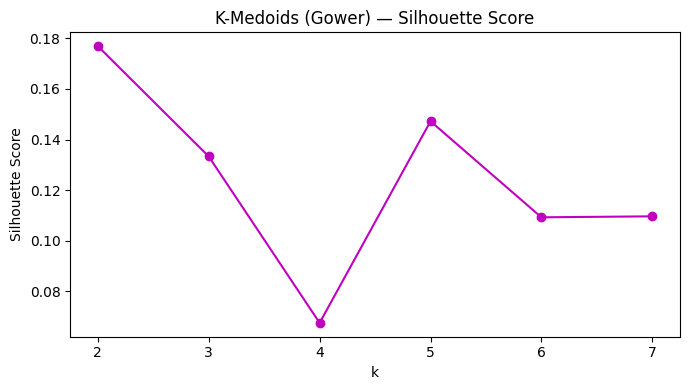


K terbaik K-Medoids: 2 | silhouette: 0.1769

Distribusi cluster K-Medoids (sample 20k):
cluster_kmedoids
0.0     9990
1.0    10010
Name: count, dtype: int64

=== Profil Medoid (representasi tiap cluster) ===
       solar_system      occupation employment_type  experience_yrs accident_history_flag psych_stress_index  hours_per_week  supervision_level  gravity_level safety_training_index  protective_gear_quality  base_salary  exposure  claim_count
104660         Zeta  Drill Operator       Full time            7.68                     0                  1              40                0.2          1.283                     5                        4      40769.0     0.462            0
49090       Epsilon  Drill Operator       Full time            7.61                     0                  1              40                0.3          0.934                     5                        4      41232.0     0.512            0


In [ ]:

# ── 3. CARI K OPTIMAL VIA SILHOUETTE ─────────────────────────────────────────
sil_kmed = []
K_range  = range(2, 8)

for k in K_range:
    kmed = KMedoids(n_clusters=k, metric='precomputed', random_state=42)
    labels = kmed.fit_predict(D)
    score  = silhouette_score(D, labels, metric='precomputed')
    sil_kmed.append(score)
    print(f"k={k} | silhouette={score:.4f}")

# ── 4. PLOT ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(K_range, sil_kmed, 'mo-')
plt.title('K-Medoids (Gower) — Silhouette Score')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# ── 5. FIT FINAL ──────────────────────────────────────────────────────────────
best_k_kmed = list(K_range)[sil_kmed.index(max(sil_kmed))]
print(f"\nK terbaik K-Medoids: {best_k_kmed} | silhouette: {max(sil_kmed):.4f}")

kmed_final = KMedoids(n_clusters=best_k_kmed, metric='precomputed', random_state=42)
kmed_final.fit(D)

# Assign label ke sample dulu
df_sample_idx = freq_imputed.sample(n=20000, random_state=42).index
freq_imputed.loc[df_sample_idx, 'cluster_kmedoids'] = kmed_final.labels_

print("\nDistribusi cluster K-Medoids (sample 20k):")
print(freq_imputed['cluster_kmedoids'].value_counts().sort_index())

# ── 6. PROFIL MEDOID ──────────────────────────────────────────────────────────
print("\n=== Profil Medoid (representasi tiap cluster) ===")
medoid_idx = kmed_final.medoid_indices_
print(df_sample_gower.iloc[medoid_idx].to_string())

# bandingin

In [ ]:
from sklearn.metrics import mean_poisson_deviance, mean_absolute_error

# ── HELPER ────────────────────────────────────────────────────────────────────
def gini_coefficient(actual, predicted, weight):
    df_temp = pd.DataFrame({'actual': np.array(actual),
                            'predicted': np.array(predicted),
                            'weight': np.array(weight)})
    df_sorted = df_temp.sort_values('predicted').reset_index(drop=True)
    cum_weight = df_sorted['weight'].cumsum() / df_sorted['weight'].sum()
    cum_actual = df_sorted['actual'].cumsum() / df_sorted['actual'].sum()
    auc  = np.trapz(cum_actual, cum_weight)
    return abs(2 * auc - 1)

# ── PASTIKAN INDEX SEJAJAR ────────────────────────────────────────────────────
# Pakai intersection index dari ketiga model di test set
common_idx = X_test.index.intersection(X_test2.index)

y_true   = y_test.loc[common_idx]
w_true   = w_test.loc[common_idx]

# GLM — predicted frequency × exposure = predicted count
glm_pred  = freq_imputed.loc[common_idx, 'pred_freq'] * w_true

# GBM Poisson
gbm_pred  = gbm_model.predict(X_test.loc[common_idx])

# GBM Tweedie — prediksi frequency × exposure
gbm2_pred = gbm2.predict(X_test2.loc[common_idx]) * w_true

# ── HITUNG METRIK ─────────────────────────────────────────────────────────────
models = {
    'GLM Poisson'  : glm_pred,
    'GBM Poisson'  : gbm_pred,
    'GBM Tweedie'  : gbm2_pred,
}

rows = []
for name, pred in models.items():
    pred   = np.array(pred).clip(1e-8)
    actual = np.array(y_true)
    weight = np.array(w_true)

    gini    = gini_coefficient(actual, pred, weight)
    mae     = mean_absolute_error(actual, pred, sample_weight=weight)
    poisson = mean_poisson_deviance(actual, pred, sample_weight=weight)
    mean_pred_freq = (pred / weight).mean()
    mean_act_freq  = (actual / weight).mean()

    rows.append({
        'Model'            : name,
        'Gini'             : round(gini, 4),
        'MAE'              : round(mae, 6),
        'Poisson Deviance' : round(poisson, 4),
        'Mean Pred Freq'   : round(mean_pred_freq, 6),
        'Mean Actual Freq' : round(mean_act_freq, 6),
    })

result = pd.DataFrame(rows).set_index('Model')
print("=== MODEL COMPARISON ===")
print(result.to_string())

# Rekomendasi otomatis
best_gini = result['Gini'].idxmax()
best_dev  = result['Poisson Deviance'].idxmin()
print(f"\nGini terbaik     : {best_gini} ({result.loc[best_gini, 'Gini']})")
print(f"Deviance terbaik : {best_dev} ({result.loc[best_dev, 'Poisson Deviance']})")

NameError: name 'X_test' is not defined

In [ ]:
# ── PERBANDINGAN KMEANS vs KMEDOIDS ──────────────────────────────────────────
from sklearn_extra.cluster import KMedoids

# KMeans sudah punya best_k dan sil_scores dari cell sebelumnya
sil_kmeans = sil_scores[best_k - 2]

# ── KMEDOIDS pakai D (gower distance matrix dari cell 1) ─────────────────────
sil_kmed = []
K_range_kmed = range(2, 8)  # batasi karena lelet

for k in K_range_kmed:
    kmed = KMedoids(n_clusters=k, metric='precomputed', random_state=42, n_init=5)
    labels = kmed.fit_predict(D)
    score  = silhouette_score(D, labels, metric='precomputed')
    sil_kmed.append(score)
    print(f"KMedoids k={k} | silhouette={score:.4f}")

best_k_kmed    = list(K_range_kmed)[sil_kmed.index(max(sil_kmed))]
sil_kmed_best  = max(sil_kmed)

# Fit final kmedoids
kmed_final = KMedoids(n_clusters=best_k_kmed, metric='precomputed', random_state=42, n_init=5)
kmed_final.fit(D)

# Assign label ke sample index
sample_idx = freq_imputed.sample(n=20000, random_state=42).index
freq_imputed['cluster_kmedoids'] = np.nan
freq_imputed.loc[sample_idx, 'cluster_kmedoids'] = kmed_final.labels_

# ── TABEL PERBANDINGAN ────────────────────────────────────────────────────────
comparison = pd.DataFrame([
    {
        'Method'         : 'KMeans + PCA',
        'Best K'         : best_k,
        'Silhouette'     : round(sil_kmeans, 4),
        'Distance'       : 'Euclidean (PCA)',
        'Covers All Data': 'Ya (predict ke full data)',
    },
    {
        'Method'         : 'KMedoids + Gower',
        'Best K'         : best_k_kmed,
        'Silhouette'     : round(sil_kmed_best, 4),
        'Distance'       : 'Gower (mixed types)',
        'Covers All Data': 'Sample 20k saja',
    },
]).set_index('Method')

print("\n=== PERBANDINGAN METODE CLUSTERING ===")
print(comparison.to_string())

# Rekomendasi
if sil_kmed_best > sil_kmeans:
    print(f"\nRekomendasi: KMedoids lebih baik (sil={sil_kmed_best:.4f} vs {sil_kmeans:.4f})")
    print("→ Gower lebih tepat untuk data campuran numerik+kategorik")
else:
    print(f"\nRekomendasi: KMeans cukup (sil={sil_kmeans:.4f} vs {sil_kmed_best:.4f})")
    print("→ Lebih cepat dan bisa predict ke seluruh data")

# Pricing

In [14]:
# Tambah grup ke sev_imputed yang belum ada
sev_imputed['occ_group']      = sev_imputed['occupation'].map(occ_map)
sev_imputed['accident_group'] = sev_imputed['accident_history_flag'].map({0: 'No', 1: 'Yes'})

In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from itertools import product

# ── 1. MODEL FREQUENCY (Poisson GLM) ─────────────────────────────────────────
# Hitung claim rate per policy
freq_imputed['claim_rate'] = freq_imputed['claim_count'] / freq_imputed['exposure']

glm_freq = smf.glm(
    formula='claim_count ~ occ_group + station_group + gear_group + accident_group',
    data=freq_imputed,
    family=sm.families.Poisson(link=sm.families.links.Log()),
    offset=np.log(freq_imputed['exposure'])
).fit()

print("=== FREQUENCY MODEL (Poisson GLM) ===")
print(glm_freq.summary())

# ── 2. MODEL SEVERITY (Gamma GLM) ─────────────────────────────────────────────
glm_sev = smf.glm(
    formula='claim_amount ~ occ_group + station_group + gear_group + accident_group',
    data=sev_imputed,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print("\n=== SEVERITY MODEL (Gamma GLM) ===")
print(glm_sev.summary())


# ── 3. PURE PREMIUM PER SEGMEN ────────────────────────────────────────────────
# Ambil unique values langsung (tanpa .cat)
occ_groups      = freq_imputed['occ_group'].unique().tolist()
station_groups  = freq_imputed['station_group'].unique().tolist()
gear_groups     = freq_imputed['gear_group'].unique().tolist()
accident_groups = freq_imputed['accident_group'].unique().tolist()

# Sort biar konsisten
occ_groups.sort()
station_groups.sort()
gear_groups.sort()
accident_groups.sort()

grid = pd.DataFrame(
    list(product(occ_groups, station_groups, gear_groups, accident_groups)),
    columns=['occ_group', 'station_group', 'gear_group', 'accident_group']
)

# Hapus baris Categorical casting yang lama, ganti jadi astype str
grid['occ_group']     = grid['occ_group'].astype(str)
grid['station_group'] = grid['station_group'].astype(str)
grid['gear_group']    = grid['gear_group'].astype(str)
grid['accident_group']= grid['accident_group'].astype(str)

grid['exposure'] = 1.0

# Predict
grid['pred_freq']    = glm_freq.predict(grid, offset=np.log(grid['exposure']))
grid['pred_sev']     = glm_sev.predict(grid)
grid['pure_premium'] = grid['pred_freq'] * grid['pred_sev']
# ── 4. TABEL PRICING LENGKAP ──────────────────────────────────────────────────
pricing_table = (
    grid[['occ_group', 'station_group', 'gear_group', 'accident_group',
          'pred_freq', 'pred_sev', 'pure_premium']]
    .sort_values('pure_premium', ascending=False)
    .reset_index(drop=True)
)

pricing_table['pred_freq']    = pricing_table['pred_freq'].round(6)
pricing_table['pred_sev']     = pricing_table['pred_sev'].round(2)
pricing_table['pure_premium'] = pricing_table['pure_premium'].round(2)

print("=== TABEL PRICING LENGKAP ===")
print(f"Total segmen: {len(pricing_table)}")
print(pricing_table.to_string(index=False))

# ── 5. SUMMARY STATISTIK PURE PREMIUM ────────────────────────────────────────
print("\n=== SUMMARY PURE PREMIUM ===")
print(f"Min    : {pricing_table['pure_premium'].min():,.2f}")
print(f"Max    : {pricing_table['pure_premium'].max():,.2f}")
print(f"Mean   : {pricing_table['pure_premium'].mean():,.2f}")
print(f"Median : {pricing_table['pure_premium'].median():,.2f}")

=== FREQUENCY MODEL (Poisson GLM) ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:               134947
Model:                            GLM   Df Residuals:                   134940
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9733.3
Date:                Mon, 09 Mar 2026   Deviance:                       15676.
Time:                        03:05:21   Pearson chi2:                 1.34e+05
No. Iterations:                     7   Pseudo R-squ. (CS):           0.001622
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------